# TP3 - Détection et Traitement des Outliers

**Difficulté:** Intermédiaire  
**Dataset:** sales_outliers.csv  
**Description:** Identification des valeurs aberrantes avec méthodes statistiques

---


## Imports des Bibliothèques


In [2]:
!pip install pandas
!pip install seaborn
!pip install numpy
!pip install matplotlib
!pip install missingno
!pip install plotly.express

In [3]:
# Bibliothèques de base
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

# Configuration des graphiques
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

# Ignorer les warnings
import warnings
warnings.filterwarnings('ignore')

# Affichage pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

print(" Bibliothèques importées avec succès!")

 Bibliothèques importées avec succès!


## Import du Dataset


In [4]:
# Charger le dataset
df = pd.read_csv(r'C:\Users\Utilisateur\Desktop\e-commerce\Pipeline-ETL---Ingestion-transformation-et-chargement-de-donn-es-multi-sources\data\sales_outliers.csv')

# Afficher les informations de base
print(f"📏 Dimensions: {df.shape[0]} lignes × {df.shape[1]} colonnes")
print(f" Taille mémoire: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print("\n" + "="*80 + "\n")

# Aperçu des données
display(df.head())
print("\n" + "="*80 + "\n")

# Informations sur les colonnes
df.info()

📏 Dimensions: 1020 lignes × 4 colonnes
 Taille mémoire: 0.04 MB




,transaction_id,amount,product,date
0,1,1458.56,B,2023-01-01
1,2,4399.43,B,2023-01-02
2,3,1298.67,C,2023-01-03
3,4,1580.76,A,2023-01-04
4,5,946.03,C,2023-01-05




<class 'pandas.DataFrame'>
RangeIndex: 1020 entries, 0 to 1019
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   transaction_id  1020 non-null   int64  
 1   amount          1020 non-null   float64
 2   product         1020 non-null   str    
 3   date            1020 non-null   str    
dtypes: float64(1), int64(1), str(2)
memory usage: 43.0 KB


## Visualisation des Valeurs Manquantes


<Figure size 1400x800 with 0 Axes>

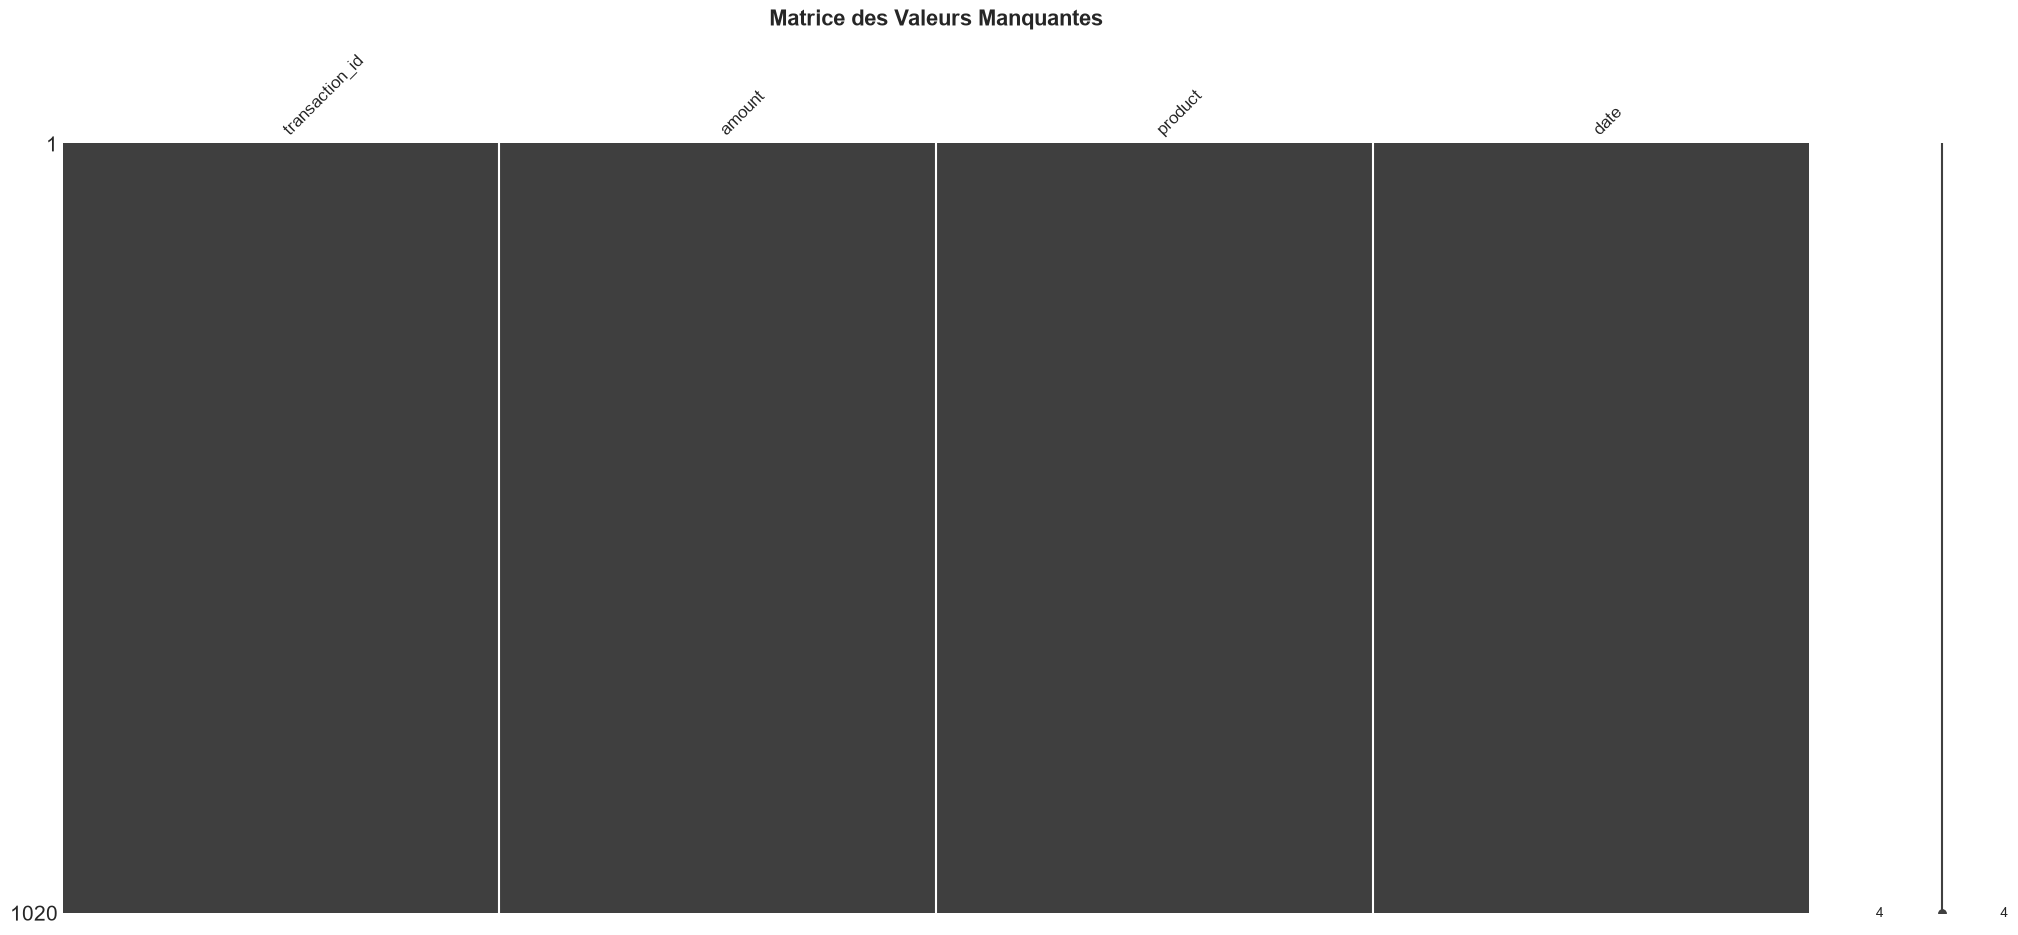


📊 Statistiques des Valeurs Manquantes:



,Nombre_Missing,Pourcentage_Missing


In [5]:
# Matrice de visualisation des valeurs manquantes
plt.figure(figsize=(14, 8))
msno.matrix(df, fontsize=12, sparkline=True)
plt.title("Matrice des Valeurs Manquantes", fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Statistiques des valeurs manquantes
missing_stats = pd.DataFrame({
    'Nombre_Missing': df.isnull().sum(),
    'Pourcentage_Missing': (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values('Pourcentage_Missing', ascending=False)

print("\n📊 Statistiques des Valeurs Manquantes:\n")
display(missing_stats[missing_stats['Nombre_Missing'] > 0])


## Questions Préalables

**Avant de commencer le TP, répondez aux questions suivantes en analysant le dataset:**

1. Quelle est la distribution de la colonne 'amount' ?
2. Y a-t-il des valeurs négatives dans les montants ?
3. Quel est le montant maximum et semble-t-il aberrant ?
4. Combien d'outliers détecte la méthode IQR pour 'amount' ?
5. Combien d'outliers détecte la méthode Z-score (threshold=3) ?
6. Les deux méthodes identifient-elles les mêmes outliers ?
7. Quelle proportion du dataset représentent les outliers ?
8. Y a-t-il une corrélation entre outliers et une catégorie spécifique ?
9. Les outliers sont-ils des erreurs ou des valeurs légitimes ?
10. Comment la moyenne change-t-elle après traitement des outliers ?


In [6]:
# 1.Quelle est la distribution de la colonne 'amount' ?

print("Réponses aux questions:")
print("="*80)

# Écrivez vos réponses ici
display(df.describe())

Réponses aux questions:


,transaction_id,amount
count,1020.00,1020.00
mean,510.50,8616.96
std,294.59,20525.04
min,1.00,79.57
25%,255.75,1441.20
50%,510.50,3152.76
75%,765.25,7221.39
max,1020.00,185913.06


In [7]:
#2. Y a-t-il des valeurs négatives dans les montants ?

print("Réponses aux questions:")
print("="*80)

# Écrivez vos réponses ici

if (df["amount"]<0).sum():
    print("les valeur est négative")
else:
    print("les valeur n'est pas négative")


Réponses aux questions:
les valeur n'est pas négative


In [8]:
#3.Combien d'outliers détecte la méthode IQR pour 'amount' ?


print("Réponses aux questions:")
print("="*80)

# Écrivez vos réponses ici
df["amount"].max()

Réponses aux questions:


np.float64(185913.06)

In [9]:
#4.Combien d'outliers détecte la méthode IQR pour 'amount' ?

print("Réponses aux questions:")
print("="*80)

# Écrivez vos réponses ici
# Détection par IQR
def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

# Utilisation
outliers, lower, upper = detect_outliers_iqr(df, 'amount')
print(f"Nombre d'outliers: {len(outliers)}")
print(f"Limites: [{lower:.2f}, {upper:.2f}]")

Réponses aux questions:
Nombre d'outliers: 105
Limites: [-7229.09, 15891.68]


In [10]:
#5.Combien d'outliers détecte la méthode Z-score (threshold=3) ?
print("Réponses aux questions:")
print("="*80)

# Écrivez vos réponses ici
from scipy import stats

# Calcul du Z-score
z_scores = np.abs(stats.zscore(df['amount']))
threshold = 3

# Détection des outliers
outliers_zScore = df[z_scores > threshold]
print(f"Outliers détectés: {len(outliers_zScore)}")

Réponses aux questions:
Outliers détectés: 22


In [11]:
#6.Les deux méthodes identifient-elles les mêmes outliers ?
print("Réponses aux questions:")
print("="*80)
# Écrivez vos réponses ici
print("nom ils ont pas les memes valeurs parce que c'est la méthode Z-score qui moins efficace dans le cas de notre jeux données")

Réponses aux questions:
nom ils ont pas les memes valeurs parce que c'est la méthode Z-score qui moins efficace dans le cas de notre jeux données


In [12]:
#7.Quelle proportion du dataset représentent les outliers ?
print("Réponses aux questions:")
print("="*80)
# Écrivez vos réponses ici
display(round((len(outliers)/len(df)*100),2))
display(round((len(outliers_zScore)/len(df)*100),2))


Réponses aux questions:


10.29

2.16

In [13]:
#8.Y a-t-il une corrélation entre outliers et une catégorie spécifique ?
print("Réponses aux questions:")
print("="*80)
# Écrivez vos réponses ici
display(outliers["product"].value_counts(normalize = True)*100 ) 
print("pas de corrélation entre outliers parce que pas une grand défirence au niveau des valeurs")


Réponses aux questions:


product
C   37.14
A   32.38
B   30.48
Name: proportion, dtype: float64

pas de corrélation entre outliers parce que pas une grand défirence au niveau des valeurs


In [14]:
#9.Les outliers sont-ils des erreurs ou des valeurs légitimes ?
print("Réponses aux questions:")
print("="*80)
# Écrivez vos réponses ici
print("on a pas des information pour justifer")



Réponses aux questions:
on a pas des information pour justifer


In [15]:
#10.Comment la moyenne change-t-elle après traitement des outliers ?
print("Réponses aux questions:")
print("="*80)
# Écrivez vos réponses ici
display(df["amount"].mean().round(2))
apres_tra = df[(df["amount"] > lower) & (df["amount"] < upper)]
apres_tra["amount"].mean().round(2)
print("avec outliers les resultats multipler par deux fois")


Réponses aux questions:


np.float64(8616.96)

avec outliers les resultats multipler par deux fois


## Étapes du TP

**Suivez les étapes ci-dessous pour nettoyer le dataset:**

### Étape 1: Visualiser la distribution avec boxplot et histogramme
### Étape 2: Calculer les statistiques descriptives
### Étape 3: Implémenter la détection par méthode IQR
### Étape 4: Implémenter la détection par Z-score
### Étape 5: Comparer les résultats des deux méthodes
### Étape 6: Décider d'une stratégie: suppression ou capping
### Étape 7: Appliquer le capping (Winsorization) aux valeurs extrêmes
### Étape 8: Visualiser la distribution avant/après traitement
### Étape 9: Calculer l'impact sur les statistiques (moyenne, écart-type)
### Étape 10: Documenter les outliers traités dans un rapport


In [16]:
import plotly.express as px

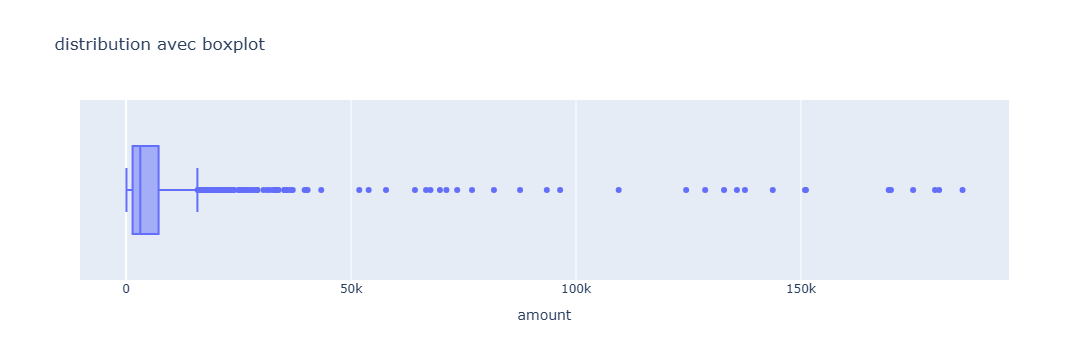

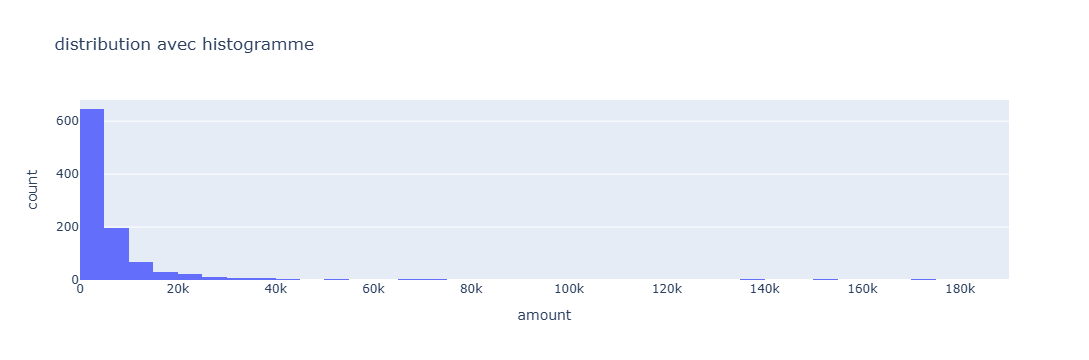

In [17]:
# ========================================
# Étape 1: Visualiser la distribution avec boxplot et histogramme
# ========================================

# TODO: Écrivez votre code ici
# Vérification
fig = px.box(df, x="amount",title = "distribution avec boxplot")
fig.show()
fig = px.histogram(df, x="amount", title = "distribution avec histogramme")
fig.show()


In [18]:
# ========================================
# Étape 2: Calculer les statistiques descriptives
# ========================================

# TODO: Écrivez votre code ici
df["amount"].describe()

# Vérification
#print(f" Étape 2 complétée")

count     1020.00
mean      8616.96
std      20525.04
min         79.57
25%       1441.20
50%       3152.76
75%       7221.39
max     185913.06
Name: amount, dtype: float64

In [19]:
# ========================================
# Étape 3: Implémenter la détection par méthode IQR
# ========================================

# TODO: Écrivez votre code ici
def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

# Utilisation
outliers, lower, upper = detect_outliers_iqr(df, 'amount')
print(f"Nombre d'outliers: {len(outliers)}")
print(f"Limites: [{lower:.2f}, {upper:.2f}]")

Nombre d'outliers: 105
Limites: [-7229.09, 15891.68]


In [20]:
# ========================================
# Étape 4: Implémenter la détection par Z-score
# ========================================

# TODO: Écrivez votre code ici
from scipy import stats
import numpy as np

# Calcul du Z-score
z_scores = np.abs(stats.zscore(df['amount']))
threshold = 3

# Détection des outliers
outliers = df[z_scores > threshold]
print(f"Outliers détectés: {len(outliers)}")

Outliers détectés: 22


In [21]:
# ========================================
# Étape 5: Comparer les résultats des deux méthodes
# ========================================

# TODO: Écrivez votre code ici
# Écrivez vos réponses ici
print("nom ils ont pas les memes valeurs parce que c'est la méthode Z-score qui moins efficace dans le cas de notre jeux données")

nom ils ont pas les memes valeurs parce que c'est la méthode Z-score qui moins efficace dans le cas de notre jeux données


In [22]:
# ========================================
# Étape 6: Décider d'une stratégie: suppression ou capping
# ========================================

# TODO: Écrivez votre code ici


# Vérification
print(f"capping pour conserver la taille ")

capping pour conserver la taille 


In [23]:
# ========================================
# Étape 7: Appliquer le capping (Winsorization) aux valeurs extrêmes
# ========================================

# TODO: Écrivez votre code ici
df_capping= df.copy()
df_capping['amount'] = df_capping['amount'].clip(lower, upper)
df_capping['amount']


0      1458.56
1      4399.43
2      1298.67
3      1580.76
4       946.03
         ...  
1015   1862.90
1016    452.57
1017   4786.74
1018   7412.97
1019   5875.88
Name: amount, Length: 1020, dtype: float64

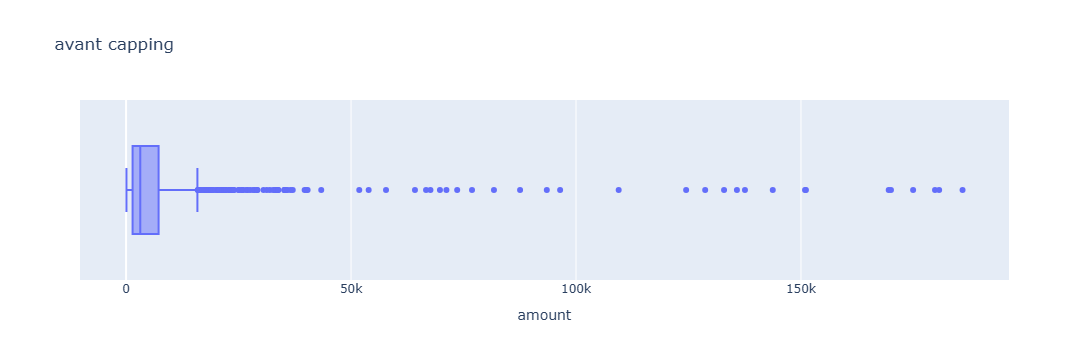

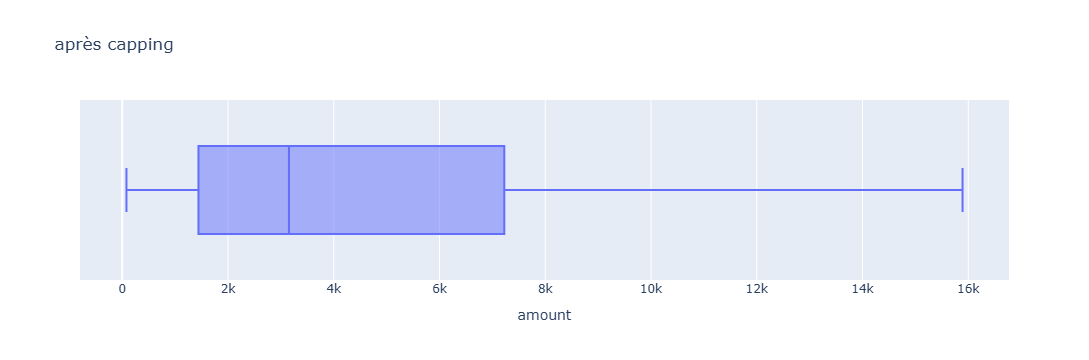

In [24]:
# ========================================
# Étape 8: Visualiser la distribution avant/après traitement
# ========================================

# TODO: Écrivez votre code ici
fig = px.box(df, x="amount",title = "avant capping ")
fig.show()
fig = px.box(df_capping, x="amount",title = "après capping")
fig.show()


In [25]:
# ========================================
# Étape 9: Calculer l'impact sur les statistiques (moyenne, écart-type)
# ========================================

# Statistiques AVANT traitement
moyenne_avant = df['amount'].mean()
std_avant = df['amount'].std()
median_avant = df['amount'].median()

# Statistiques APRÈS traitement (capping)
moyenne_apres = df_capping['amount'].mean()
std_apres = df_capping['amount'].std()
median_apres = df_capping['amount'].median()

print("=" * 80)
print(" " * 20 + "IMPACT DU CAPPING SUR LES STATISTIQUES")
print("=" * 80)

print(f"\n{'Statistique':.<30} {'Avant capping':.<20} {'Après capping':.<20} {'Différence':.<20}")
print("-" * 80)
print(f"{'Moyenne':.<30} {moyenne_avant:<20.2f} {moyenne_apres:<20.2f} {moyenne_avant - moyenne_apres:<20.2f}")
print(f"{'Écart-type':.<30} {std_avant:<20.2f} {std_apres:<20.2f} {std_avant - std_apres:<20.2f}")
print(f"{'Médiane':.<30} {median_avant:<20.2f} {median_apres:<20.2f} {median_avant - median_apres:<20.2f}")

print("\n" + "=" * 80)
print(" INTERPRÉTATION :")
print(f"  • La moyenne a {'baissé' if moyenne_avant > moyenne_apres else 'augmenté'} de {abs(moyenne_avant - moyenne_apres):.2f}")
print(f"  • L'écart-type a {'diminué' if std_avant > std_apres else 'augmenté'} de {abs(std_avant - std_apres):.2f}")
print(f"  • La médiane est {'restée stable' if abs(median_avant - median_apres) < 100 else 'a changé'}")
print("=" * 80)


# Vérification
print(f" Étape 9 complétée")

                    IMPACT DU CAPPING SUR LES STATISTIQUES

Statistique................... Avant capping....... Après capping....... Différence..........
--------------------------------------------------------------------------------
Moyenne....................... 8616.96              5181.40              3435.55             
Écart-type.................... 20525.04             4920.61              15604.43            
Médiane....................... 3152.76              3152.76              0.00                

 INTERPRÉTATION :
  • La moyenne a baissé de 3435.55
  • L'écart-type a diminué de 15604.43
  • La médiane est restée stable
 Étape 9 complétée


In [28]:
# ========================================
# Étape 10: Documenter les outliers traités dans un rapport
# ========================================

# Calcul du nombre d'outliers traités
nb_outliers_iqr = 105
nb_outliers_zscore = 22

# Rapport de nettoyage TP3
rapport_tp3 = {
    'Dimensions_initiales': f"({df.shape[0]} lignes, {df.shape[1]} colonnes)",
    'Dimensions_finales': f"({df_capping.shape[0]} lignes, {df_capping.shape[1]} colonnes)",
    'Lignes_supprimées': 0,  # On a utilisé le capping, pas la suppression
    'Colonnes_supprimées': 0,
    'Valeurs_manquantes_traitées': 0,  # Déjà fait au TP1
    'Doublons_supprimés': 0,  # Déjà fait au TP2
    'Outliers_traités': f"{nb_outliers_iqr} (IQR) / {nb_outliers_zscore} (Z-score)",
    'Méthode_utilisée': 'Capping (Winsorization)',
    'Limites_IQR': f"[{lower:.2f}, {upper:.2f}]",
    'Transformations_appliquées': [
        '1. Visualisation de la distribution (boxplot + histogramme)',
        '2. Calcul des statistiques descriptives',
        '3. Détection des outliers par méthode IQR (105 outliers)',
        '4. Détection des outliers par méthode Z-score (22 outliers)',
        '5. Comparaison des deux méthodes',
        '6. Décision : Capping pour conserver la taille du dataset',
        '7. Application du capping avec clip(lower, upper)',
        '8. Visualisation avant/après traitement',
        '9. Analyse de l\'impact sur moyenne et écart-type'
    ]
}

print("=" * 80)
print(" " * 25 + "RAPPORT TP3 - GESTION DES OUTLIERS")
print("=" * 80)

for key, value in rapport_tp3.items():
    print(f"{key:.<40} {value}")

print("=" * 80)
print("\nTP3 : Gestion des Outliers terminé avec succès!")
print("=" * 80)


# Vérification
print(f" Étape 10 complétée")

                         RAPPORT TP3 - GESTION DES OUTLIERS
Dimensions_initiales.................... (1020 lignes, 4 colonnes)
Dimensions_finales...................... (1020 lignes, 4 colonnes)
Lignes_supprimées....................... 0
Colonnes_supprimées..................... 0
Valeurs_manquantes_traitées............. 0
Doublons_supprimés...................... 0
Outliers_traités........................ 105 (IQR) / 22 (Z-score)
Méthode_utilisée........................ Capping (Winsorization)
Limites_IQR............................. [-7229.09, 15891.68]
Transformations_appliquées.............. ['1. Visualisation de la distribution (boxplot + histogramme)', '2. Calcul des statistiques descriptives', '3. Détection des outliers par méthode IQR (105 outliers)', '4. Détection des outliers par méthode Z-score (22 outliers)', '5. Comparaison des deux méthodes', '6. Décision : Capping pour conserver la taille du dataset', '7. Application du capping avec clip(lower, upper)', '8. Visualisation av

## Rapport Final

**Créez un rapport résumant toutes les transformations effectuées**


In [27]:
# Rapport de nettoyage
rapport = {
    'Dimensions_initiales': df.shape,
    'Dimensions_finales': df.shape,  # À mettre à jour avec df_clean
    'Lignes_supprimées': 0,
    'Colonnes_supprimées': 0,
    'Valeurs_manquantes_traitées': 0,
    'Doublons_supprimés': 0,
    'Outliers_traités': 0,
    'Transformations_appliquées': []
}

print("=" * 80)
print(" " * 25 + " RAPPORT DE NETTOYAGE")
print("=" * 80)

for key, value in rapport.items():
    print(f"{key:.<40} {value}")

print("=" * 80)
print("\n✅ TP terminé avec succès!")

                          RAPPORT DE NETTOYAGE
Dimensions_initiales.................... (1020, 4)
Dimensions_finales...................... (1020, 4)
Lignes_supprimées....................... 0
Colonnes_supprimées..................... 0
Valeurs_manquantes_traitées............. 0
Doublons_supprimés...................... 0
Outliers_traités........................ 0
Transformations_appliquées.............. []

✅ TP terminé avec succès!
